<div class="alert alert-block alert-warning">
<h1>Learning Objectives</h1>
* Understand the role of **Logistic Regression** as a linear classifier for binary classification.
* Understand the role of a **Support Vector Machine** as a margin-based classifier.
* Build sklearn **pipelines** for both methods using the same MACCS input used in earlier notebooks.
* Generate **predicted classes** and **class probabilities or scores**.
* Evaluate the models using:

  * confusion matrices
  * ROC curves
  * AUC
  * standard classification metrics
* Compare LR and SVM to previously studied models.
</div>

# 1 Why Study Logistic Regression and SVM?
In previous notebooks, we explored two major approaches to classification:

- Naïve Bayes, which estimates class probabilities based on feature evidence
- Decision Trees and Random Forests, which partition feature space through hierarchical rules

In this notebook, we introduce two additional classifier families:

- Logistic Regression, which models the probability of class membership using a weighted linear combination of features
- Support Vector Machines (SVMs), which focus on finding a decision boundary that maximizes separation between classes

These models approach the same fingerprint data from a different perspective. Instead of building trees or combining independent probabilities, they define decision boundaries in feature space. This allows us to ask an important question: How does the choice of learning algorithm affect what we can extract from the same molecular fingerprint representation?

| Model Type            | Core Idea                          | What It Learns                      |
|----------------------|-----------------------------------|------------------------------------|
| Naïve Bayes          | Probabilistic independence        | Feature evidence for each class     |
| Decision Tree        | Recursive splitting               | Rule-based partitions              |
| Random Forest        | Ensemble of trees                 | Robust nonlinear patterns          |
| Logistic Regression  | Linear weighted model             | Additive feature contributions     |
| SVM                  | Maximum-margin boundary           | Optimal separating hyperplane      |

# 2 Load the Aromatase MACCS Data


In [1]:
# Load MACCS fingerprint dataset

from pathlib import Path
import pandas as pd

data_path = Path(
    "data/AID743139/features/"
    "AID743139_MACCS_activities_noSalt_20260205.csv"
)

df = pd.read_csv(data_path)

# Separate features and labels
label_column = "activity"
maccs_columns = [c for c in df.columns if c.startswith("maccs")]

X = df[maccs_columns]
y = df[label_column]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (6793, 167)
Label vector shape: (6793,)


# 3 Pipelines Revisited

Although the MACCS fingerprints have already been generated, we still need to think carefully about how those features are passed into a machine-learning model. In earlier notebooks, we introduced the idea of a pipeline as a structured workflow that connects preprocessing steps to a classifier.

That same idea remains important here. Even when the feature matrix is already available, we may still want to apply preprocessing steps such as removing invariant fingerprint bits. More importantly, we want to ensure that any transformation learned from the training data is applied to the test data in exactly the same way.

In scikit-learn, a `Pipeline` allows us to bundle preprocessing and model fitting into a single object. This improves reproducibility, reduces the risk of accidentally treating training and test data differently, and makes it easy to swap one classifier for another while keeping the rest of the workflow unchanged.

In this notebook, we will continue using pipelines so that Logistic Regression and Support Vector Machine models can be compared fairly on the same fingerprint representation.

In [2]:
from sklearn.model_selection import train_test_split

# Create reproducible stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=3100
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

print("\nClass distribution")
print("Full dataset:")
print(y.value_counts(normalize=True))

print("\nTraining set:")
print(y_train.value_counts(normalize=True))

print("\nTest set:")
print(y_test.value_counts(normalize=True))

X_train shape: (6113, 167)
X_test shape:  (680, 167)
y_train shape: (6113,)
y_test shape:  (680,)

Class distribution
Full dataset:
activity
0    0.890623
1    0.109377
Name: proportion, dtype: float64

Training set:
activity
0    0.890561
1    0.109439
Name: proportion, dtype: float64

Test set:
activity
0    0.891176
1    0.108824
Name: proportion, dtype: float64


# 4 Logistic Regression
## 4.1 What Is Logistic Regression?

Logistic Regression is a classification model that estimates the probability that a sample belongs to a particular class.

In our case, the task is binary classification:
- 0 → inactive compound  
- 1 → active compound  

At its core, Logistic Regression begins with a **linear combination of features**:

$$
z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
$$

- $x_i$ = fingerprint bits (MACCS keys: 0 or 1)  
- $w_i$ = learned weights for each feature  
- $b$ = intercept (bias term)  

This looks similar to a linear regression model. However, the output $z$ can take any real value, from $-\infty$ to $+\infty$, which is not suitable for representing probabilities.

## 4.1.2 The Logistic (Sigmoid) Function

To convert the linear output into a probability, Logistic Regression applies the logistic (sigmoid) function:
$$P(y=1|x) = \frac{1}{1 + e^{-z}}$$
The sigmoid function transforms any real-valued input into a value between 0 and 1. This allows the model to interpret its output as a probability.

Conceptually, the sigmoid acts as a smooth threshold:

- When $z$ is very large and positive, $e^{-z}$ becomes very small  
  → the probability approaches 1  

- When $z$ is very large and negative, $e^{-z}$ becomes very large  
  → the probability approaches 0  

- When $z = 0$:
  $$
  P(y=1|x) = \frac{1}{1 + e^0} = \frac{1}{2}
  $$
  → the model is maximally uncertain (50% probability)

This gives the sigmoid an S-shaped curve:

- small changes near $z = 0$ strongly affect the probability  
- very large positive or negative values "saturate" near 1 or 0  

So the model works in two steps:
1. Compute a weighted sum of fingerprint features ($z$)  
2. Convert that value into a probability using the sigmoid function

### Visualizing the Sigmoid Function

To better understand how the sigmoid function behaves, we can plot it over a range of values for $z$.

This plot shows how the linear model output ($z$) is transformed into a probability between 0 and 1. Notice how:

- The curve is S-shaped  
- The steepest region occurs near $z = 0$  
- The output approaches 0 and 1 asymptotically  

This visualization helps explain how Logistic Regression converts a linear score into a probability.


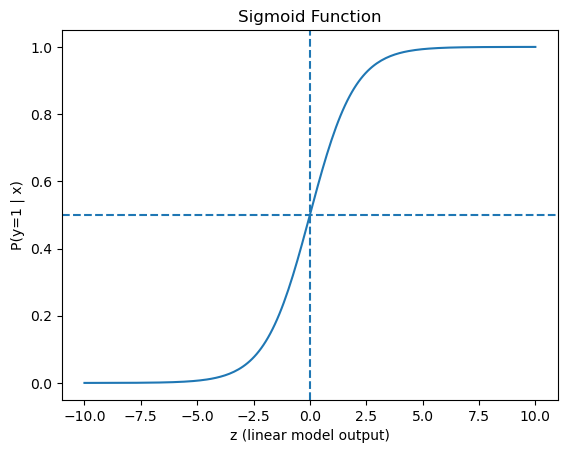

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate range of z values
z = np.linspace(-10, 10, 200)

# Compute sigmoid values
p = sigmoid(z)

# Plot
plt.figure()
plt.plot(z, p)
plt.xlabel("z (linear model output)")
plt.ylabel("P(y=1 | x)")
plt.title("Sigmoid Function")
plt.axhline(0.5, linestyle="--")  # threshold line
plt.axvline(0, linestyle="--")    # decision boundary
plt.show()


## 4.1.3 From Probability to Classification

Once the probability is computed, the model must decide:

> Should this compound be classified as active or inactive?

By default, scikit-learn uses a threshold of 0.5:

- P$\text{active}$ $\geq 0.5$ → predict active  
- P$\text{active}$ < 0.5$ → predict inactive  

This connects directly to earlier discussions of:
- `.predict()` → applies a threshold  
- `.predict_proba()` → returns the probability  

This also ties into ROC curves and threshold selection:
- different thresholds produce different confusion matrices  
- Logistic Regression naturally provides the probability scores needed for ROC analysis  

---

## 4.1.4 Interpreting the Model

Each weight $w_i$ represents how strongly a fingerprint bit contributes to predicting activity:

- Positive weight → increases probability of being active  
- Negative weight → decreases probability  
- Larger magnitude → stronger influence  

In this sense, Logistic Regression provides an additive model of evidence, each fingerprint bit contributes independently to the final prediction. This is conceptually similar to Naïve Bayes, but instead of multiplying probabilities, Logistic Regression adds weighted contributions.

#### How Are the Weights Learned?

The weights in Logistic Regression are not assigned manually. They are learned from the training data during the fitting process.

At a high level, the model works as follows:

1. The model begins with initial guesses for the weights  
2. It uses these weights to compute predicted probabilities for each training example  
3. It compares those predictions to the true labels (active or inactive)  
4. It adjusts the weights to reduce the difference between predicted and actual values  
5. This process is repeated until the model converges to a stable set of weights  

The goal is to find the set of weights that best explain the relationship between molecular fingerprints and activity.

In practical terms:

- Features that frequently appear in active compounds tend to receive positive weights  
- Features that are associated with inactive compounds tend to receive negative weights  
- Features that do not help distinguish between classes tend to receive weights near zero  

This process is similar to fitting parameters in a scientific model: the weights are adjusted to minimize the difference between model predictions and observed data.

## 4.1.5 Logistic Regression vs Earlier Models

It is helpful to contrast Logistic Regression with the models we have already studied:

- Naïve Bayes: Combines feature evidence using probability rules (with independence assumptions)

- Decision Trees / Random Forests: Learn rules that partition feature space into regions

- Logistic Regression: Learns a single global decision boundary defined by a weighted sum of features

Logistic Regression is often used as a baseline model because it provides a simple and interpretable reference point. By comparing more complex models to this baseline, we can determine whether additional model complexity actually improves predictive performance on the same fingerprint data.

In the next section, we will build a pipeline that applies Logistic Regression to the MACCS fingerprint dataset and 

## 4.2 Build the Logistic Regression Pipeline
### Logistic Regression Parameters

The `LogisticRegression()` classifier has many parameters, but only a few are especially important at this stage. In this notebook, we begin with a simple version of the model and postpone more extensive hyperparameter tuning until later.

| Parameter | What it controls | Typical role in this notebook |
|---|---|---|
| `penalty` | Type of regularization applied to the model coefficients | Usually left at the default (`'l2'`) for a stable first model |
| `C` | Inverse of regularization strength | Smaller values give stronger regularization; default is often a good starting point |
| `solver` | Optimization algorithm used to fit the model | The default solver usually works well for moderate-sized problems |
| `max_iter` | Maximum number of optimization iterations | Often increased (for example to `1000`) to avoid convergence warnings |
| `class_weight` | Adjusts importance of each class during training | Can be `None`, `"balanced"`, or a custom dictionary |
| `random_state` | Controls randomness for solvers that use randomization | Helps reproducibility when relevant |
| `fit_intercept` | Whether to include an intercept term | Usually left as `True` |
| `tol` | Tolerance for stopping the optimization | Smaller values may require more iterations |

#### Understanding `class_weight`

The `class_weight` parameter is different from the feature weights learned by the model. While feature weights ($w_i$) determine how individual fingerprint bits influence the prediction, `class_weight` controls how much importance is given to each class during training.

This is particularly important for imbalanced datasets, where one class (such as inactive compounds) may be much more common than the other.

| Value            | Meaning                              | When to use                              |
| ---------------- | ------------------------------------ | ---------------------------------------- |
| `None`           | No weighting                         | Baseline model                           |
| `"balanced"`     | Auto-adjust based on class frequency | Most common starting point for imbalance |
| `{0: w0, 1: w1}` | Manual weighting                     | When you want control over trade-offs    |


For this first Logistic Regression model, we use:

```python
LogisticRegression(max_iter=1000)

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression

# Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[
    ("var_filter", VarianceThreshold(threshold=0.0)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit pipeline
lr_pipeline.fit(X_train, y_train)

# Predict classes and probabilities on test set
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("First 10 predicted classes:", y_pred_lr[:10])
print("First 10 predicted probabilities:", y_prob_lr[:10])
lr_pipeline

First 10 predicted classes: [0 0 1 0 0 0 0 0 0 0]
First 10 predicted probabilities: [0.00717629 0.03504803 0.55400672 0.03626497 0.17991293 0.00233865
 0.35529472 0.02754376 0.03755857 0.30729229]


,steps,"[('var_filter', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,threshold,0.0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


## 4.3 Fit the Model

We now fit the Logistic Regression pipeline using the training data. During this step:

- The variance filter identifies and removes invariant MACCS bits  
- The Logistic Regression model learns weights for the remaining features  

The fitted pipeline stores both the preprocessing and the trained model, allowing us to apply the same transformations when making predictions on new data.

In [6]:
# Fit the Logistic Regression pipeline
lr_pipeline.fit(X_train, y_train)

# Access the fitted classifier
lr_model = lr_pipeline.named_steps["classifier"]

print("Model fitted successfully.")
print("Number of features used:", lr_model.coef_.shape[1])

Model fitted successfully.
Number of features used: 162


## 4.4 Predict Classes and Probabilities
Once the pipeline has been fit, we can use it to generate predictions for the test set.
Logistic Regression provides two types of outputs:

- `.predict()`  
  Returns the predicted class labels (0 = inactive, 1 = active) using a default threshold of 0.5  

- `.predict_proba()`  
  Returns the predicted probabilities for each class  

For binary classification, `predict_proba()` returns two columns:
- probability of class 0 (inactive)  
- probability of class 1 (active)  

We will extract the probability of the active class (class = 1), which will be used for ROC analysis and threshold-based evaluation.

In [7]:
# Predict class labels
y_pred_lr = lr_pipeline.predict(X_test)

# Predict class probabilities
y_prob_lr = lr_pipeline.predict_proba(X_test)

# Extract probability of the positive class (active = 1)
y_score_lr = y_prob_lr[:, 1]

# Display a few results
print("First 10 predicted classes:", y_pred_lr[:10])
print("First 10 predicted probabilities (active):", y_score_lr[:10])

First 10 predicted classes: [0 0 1 0 0 0 0 0 0 0]
First 10 predicted probabilities (active): [0.00717629 0.03504803 0.55400672 0.03626497 0.17991293 0.00233865
 0.35529472 0.02754376 0.03755857 0.30729229]


In [8]:
print("First 5 full probability rows:\n")
print(y_prob_lr[:5])

First 5 full probability rows:

[[0.99282371 0.00717629]
 [0.96495197 0.03504803]
 [0.44599328 0.55400672]
 [0.96373503 0.03626497]
 [0.82008707 0.17991293]]


The predicted class labels are derived from the probabilities using a threshold (default = 0.5). This means that:

- Changing the threshold would change the predicted classes  
- The probabilities themselves contain more information than the final class labels  

This is why probability outputs are essential for ROC curves and AUC calculations.


## 4.5 Evaluate Logistic Regression

We now evaluate the Logistic Regression model using the test set.

As in earlier notebooks, we use multiple metrics to assess model performance:

- **Confusion Matrix**  
  Summarizes correct and incorrect classifications (TN, FP, FN, TP)

- **Classification Report**  
  Provides precision, recall, and F1-score for each class

- **ROC Curve and AUC**  
  Evaluate how well the model separates active and inactive compounds across all classification thresholds

Together, these metrics provide a more complete view of model performance than any single measure.

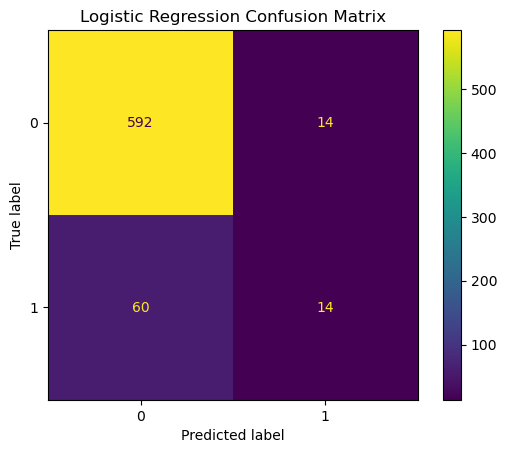

TN=592, FP=14, FN=60, TP=14

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       606
           1       0.50      0.19      0.27        74

    accuracy                           0.89       680
   macro avg       0.70      0.58      0.61       680
weighted avg       0.86      0.89      0.87       680



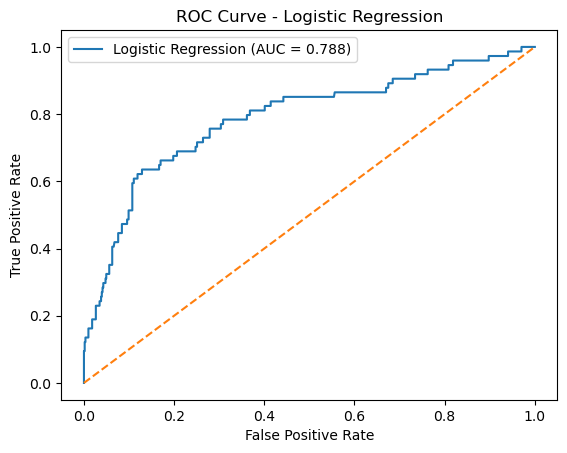

AUC: 0.788


In [9]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt

# --- Confusion Matrix ---
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Optional: unpack values
tn, fp, fn, tp = cm_lr.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# --- Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# --- ROC Curve and AUC ---
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_score_lr)
auc_lr = roc_auc_score(y_test, y_score_lr)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print(f"AUC: {auc_lr:.3f}")

Discuss imbalance

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# ---------------------------
# Build both pipelines
# ---------------------------
lr_pipeline = Pipeline(steps=[
    ("var_filter", VarianceThreshold(threshold=0.0)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    ))
])

lr_pipeline_bal = Pipeline(steps=[
    ("var_filter", VarianceThreshold(threshold=0.0)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42
    ))
])

# ---------------------------
# Fit both models
# ---------------------------
lr_pipeline.fit(X_train, y_train)
lr_pipeline_bal.fit(X_train, y_train)

# ---------------------------
# Predict classes and probabilities
# ---------------------------
y_pred_lr = lr_pipeline.predict(X_test)
y_score_lr = lr_pipeline.predict_proba(X_test)[:, 1]

y_pred_lr_bal = lr_pipeline_bal.predict(X_test)
y_score_lr_bal = lr_pipeline_bal.predict_proba(X_test)[:, 1]

# ---------------------------
# Confusion matrices
# ---------------------------
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr_bal = confusion_matrix(y_test, y_pred_lr_bal)

tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
tn_bal, fp_bal, fn_bal, tp_bal = cm_lr_bal.ravel()

# ---------------------------
# Metric summary table
# ---------------------------
results = pd.DataFrame([
    {
        "Model": "LR Default",
        "TN": tn_lr,
        "FP": fp_lr,
        "FN": fn_lr,
        "TP": tp_lr,
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision (Active)": precision_score(y_test, y_pred_lr, zero_division=0),
        "Recall (Active)": recall_score(y_test, y_pred_lr, zero_division=0),
        "F1 (Active)": f1_score(y_test, y_pred_lr, zero_division=0),
        "AUC": roc_auc_score(y_test, y_score_lr)
    },
    {
        "Model": "LR Balanced",
        "TN": tn_bal,
        "FP": fp_bal,
        "FN": fn_bal,
        "TP": tp_bal,
        "Accuracy": accuracy_score(y_test, y_pred_lr_bal),
        "Precision (Active)": precision_score(y_test, y_pred_lr_bal, zero_division=0),
        "Recall (Active)": recall_score(y_test, y_pred_lr_bal, zero_division=0),
        "F1 (Active)": f1_score(y_test, y_pred_lr_bal, zero_division=0),
        "AUC": roc_auc_score(y_test, y_score_lr_bal)
    }
])

# Round numeric columns for readability
results = results.round(3)

print("Comparison of Logistic Regression models:\n")
display(results)

print("\nConfusion Matrix - LR Default")
print(cm_lr)

print("\nConfusion Matrix - LR Balanced")
print(cm_lr_bal)

Comparison of Logistic Regression models:



,Model,TN,FP,FN,TP,Accuracy,Precision (Active),Recall (Active),F1 (Active),AUC
0,LR Default,592,14,60,14,0.891,0.500,0.189,0.275,0.788
1,LR Balanced,469,137,23,51,0.765,0.271,0.689,0.389,0.781



Confusion Matrix - LR Default
[[592  14]
 [ 60  14]]

Confusion Matrix - LR Balanced
[[469 137]
 [ 23  51]]


The default Logistic Regression model achieves high accuracy, but this performance is driven primarily by correctly identifying inactive compounds. The recall for active compounds is low (0.19), indicating that most active compounds are missed.

When `class_weight="balanced"` is applied, the model shifts its behavior. The recall for active compounds increases substantially (0.69), meaning that most actives are now detected. However, this comes at the cost of an increase in false positives and a decrease in overall accuracy.

The AUC remains nearly unchanged, indicating that the model's ability to distinguish between active and inactive compounds has not significantly changed. Instead, the difference lies in how the model makes classification decisions.

In cheminformatics missing actives (FN) is often worse than having extra candidates (FP), and so the balanced model is probably preferred.

# 5 Support Vector Machine
## 5.1 What Is an SVM?
Support Vector Machines (SVMs) are supervised learning models that classify data by finding a decision boundary that maximizes the margin between classes. Unlike Logistic Regression, which focuses on modeling probabilities, SVM focuses on the geometry of the data.

Only a subset of the training data—called "support vectors" determines the position of the boundary. This makes SVM particularly effective in high-dimensional spaces, such as those created by molecular fingerprints.

In scikit-learn, two primary implementations are available:

* **SVC**: A flexible implementation that supports kernels and probability estimates
* **LinearSVC**: A faster implementation optimized for large, high-dimensional datasets, but without probability outputs

In this section, we begin with a linear SVM using SVC to maintain consistency with earlier probabilistic evaluation methods.


### Support Vectors: The Critical Data Points

In a Support Vector Machine, the decision boundary is not determined by all training data. Instead, it is defined by a small subset of points called support vectors.

These are the data points closest to the boundary—typically those that are hardest to classify. Points far from the boundary do not influence the model once it is trained.

Although this may resemble unsupervised methods that identify structure in data, SVM is fully supervised. The boundary is constructed using known class labels, and the support vectors arise from the constraints imposed by those labels.

In cheminformatics applications, support vectors often correspond to molecules with ambiguous or borderline activity, making them especially important for understanding model behavior.


## 5.2 Build the SVM Pipeline
In this step, we define a machine learning pipeline for the Support Vector Machine (SVM) model. As in previous sections, the pipeline combines feature preprocessing with the classifier into a single, reproducible workflow.

We first apply a variance threshold to remove features that do not vary across the dataset, ensuring that only informative MACCS keys are passed to the model. The classifier is a linear SVM implemented using `SVC` from `sklearn.svm`, which allows us to compute class probabilities for downstream evaluation (e.g., ROC and AUC).

At this stage, we are only defining the structure of the model. No learning has occurred yet—the identification of support vectors and the optimization of the decision boundary will take place during the fitting step.


In [1]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ('var', VarianceThreshold(threshold=0.0)),
    ('clf', SVC(kernel='linear', probability=True, random_state=3100))
])

## 5.3 Fit the Model

### Reload data and create train/test split
After restarting the kernel, we reload the MACCS fingerprint dataset and recreate the same stratified train/test split used in earlier sections. This ensures that model training and evaluation remain consistent across algorithms, allowing for direct comparison of results.

The feature matrix (X) contains the MACCS keys, and the label vector (y) contains the activity classification. A stratified split is used to preserve the class distribution in both the training and test sets



In [2]:
# Reload data and create train/test split

from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
data_path = Path(
    "data/AID743139/features/"
    "AID743139_MACCS_activities_noSalt_20260205.csv"
)

df = pd.read_csv(data_path)

# Separate features and labels
label_column = "activity"
maccs_columns = [c for c in df.columns if c.startswith("maccs")]

X = df[maccs_columns]
y = df[label_column]

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=3100
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (6113, 167) | X_test: (680, 167)
y_train: (6113,) | y_test: (680,)


### Fit the Model
We now fit the SVM pipeline using the training data. During this step, the model learns the optimal decision boundary that separates active and inactive compounds by maximizing the margin between classes.

Unlike Logistic Regression, where all data points contribute to the model, the SVM identifies a subset of critical points—called **support vectors**—that define this boundary. These support vectors are determined during the fitting process and will be examined after training.

In [5]:
# Fit the SVM pipeline
svm_pipeline.fit(X_train, y_train)

# Access the fitted classifier
svm_model = svm_pipeline.named_steps["clf"]

print("Model fitted successfully.")

# Basic diagnostic output
print("Number of support vectors:", len(svm_model.support_))
print("Support vectors per class:", svm_model.n_support_)

Model fitted successfully.
Number of support vectors: 1662
Support vectors per class: [993 669]


### Model Fit Summary

The SVM model has been successfully trained. The output shows the total number of support vectors and how they are distributed across the two classes.

A relatively large number of support vectors indicates that many data points lie near the decision boundary or within the margin. This suggests that the classes are not cleanly separable and that the model must rely on a substantial portion of the data to define the boundary.

In this case, the imbalance in support vectors between classes reflects the underlying class distribution and the complexity of separating active and inactive compounds in this dataset.

## 5.4 Predict Classes and Probabilities

We now evaluate the performance of the trained SVM model on the test set. As in previous sections, we compute classification metrics derived from the confusion matrix, along with ROC and AUC to assess the model’s ability to distinguish between active and inactive compounds across different thresholds.

Because we used an SVM implementation that supports probability estimates, we can directly compare these results to those obtained from Logistic Regression.


In [6]:
# Generate predictions and probabilities

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions (default threshold = 0.5)
y_pred = svm_pipeline.predict(X_test)

# Probabilities for ROC/AUC
y_prob = svm_pipeline.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Print results
print("Confusion Matrix:")
print(cm)

print("\nMetrics:")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"AUC      : {auc:.3f}")

Confusion Matrix:
[[606   0]
 [ 74   0]]

Metrics:
Accuracy : 0.891
Precision: 0.000
Recall   : 0.000
F1 Score : 0.000
AUC      : 0.774


/home/rebelford/miniconda3/envs/nbi/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Interpreting SVM Performance

The confusion matrix shows that the model predicts all compounds as inactive at the default decision threshold of 0.5. As a result, no active compounds are identified, leading to precision, recall, and F1 scores of zero.

This behavior triggers a warning because precision is undefined when no positive predictions are made.

However, the AUC value (0.774) indicates that the model still has meaningful discriminatory power. This suggests that the predicted probabilities contain useful information, but the default threshold is too strict for identifying active compounds.

This highlights an important distinction: classification metrics depend on a chosen threshold, while AUC reflects overall ranking performance across all possible thresholds.
### Selecting an Optimal Threshold (Youden’s J)

The previous results showed that the default threshold of 0.5 leads to poor classification performance, even though the model has reasonable AUC. This indicates that the predicted probabilities contain useful information, but the decision threshold is not appropriate.

To address this, we use **Youden’s J statistic**, defined as:

J = TPR − FPR

This metric identifies the threshold that maximizes the difference between the true positive rate and false positive rate, providing a balanced trade-off between sensitivity and specificity.

We now compute the optimal threshold and re-evaluate the model using this value.

In [7]:
from sklearn.metrics import roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute Youden's J statistic
j_scores = tpr - fpr

# Find optimal threshold
best_idx = j_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Optimal threshold (Youden's J): {best_threshold:.3f}")

# Apply new threshold
y_pred_opt = (y_prob >= best_threshold).astype(int)

# Confusion matrix
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm_opt.ravel()

# Metrics
accuracy_opt = accuracy_score(y_test, y_pred_opt)
precision_opt = precision_score(y_test, y_pred_opt, zero_division=0)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

# Print results
print("\nConfusion Matrix (Optimized Threshold):")
print(cm_opt)

print("\nMetrics (Optimized Threshold):")
print(f"Accuracy : {accuracy_opt:.3f}")
print(f"Precision: {precision_opt:.3f}")
print(f"Recall   : {recall_opt:.3f}")
print(f"F1 Score : {f1_opt:.3f}")

Optimal threshold (Youden's J): 0.114

Confusion Matrix (Optimized Threshold):
[[503 103]
 [ 24  50]]

Metrics (Optimized Threshold):
Accuracy : 0.813
Precision: 0.327
Recall   : 0.676
F1 Score : 0.441


### Performance After Threshold Optimization

Using Youden’s J statistic, we identified an optimal decision threshold of 0.114, which is substantially lower than the default value of 0.5.

At this optimized threshold, the model now correctly identifies a large portion of active compounds (recall = 0.676), compared to zero recall at the default threshold. However, this improvement comes with an increase in false positives, resulting in a lower precision (0.327).

The overall F1 score (0.441) reflects a more balanced performance between precision and recall, and the accuracy (0.813) remains reasonably high.

This comparison highlights a critical concept: while the underlying model has not changed, adjusting the decision threshold can dramatically alter classification performance. The default threshold is not always appropriate, particularly for imbalanced datasets or when the cost of false negatives is high.

In this context, lowering the threshold makes the model more sensitive to identifying potentially active compounds, which may be desirable in early-stage screening where missing an active compound is costly.


### ROC Curve with Optimal Threshold

We now visualize the ROC curve for the SVM model and highlight the point corresponding to the optimal threshold identified using Youden’s J statistic.

This point represents the balance between the true positive rate (sensitivity) and false positive rate at the selected threshold, providing a visual interpretation of the trade-off made during threshold optimization.

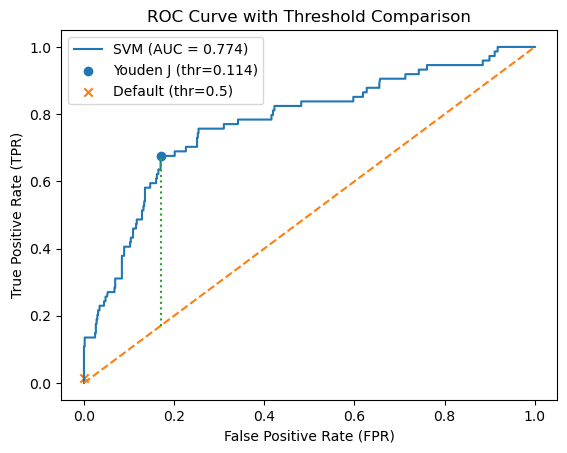

Default threshold (0.5):
FPR: 0.000, TPR: 0.014

Youden's J threshold:
Threshold: 0.114
FPR: 0.170, TPR: 0.676


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Find threshold closest to 0.5 ---
default_threshold = 0.5
default_idx = np.argmin(np.abs(thresholds - default_threshold))

default_fpr = fpr[default_idx]
default_tpr = tpr[default_idx]

# --- Already computed ---
# best_idx, best_fpr, best_tpr

# --- Plot ---
plt.figure()

# ROC curve
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc:.3f})")

# Random line
plt.plot([0, 1], [0, 1], linestyle='--')

# Optimal threshold (Youden J)
plt.scatter(best_fpr, best_tpr, label=f"Youden J (thr={best_threshold:.3f})")

# Default threshold (0.5)
plt.scatter(default_fpr, default_tpr, marker='x', label="Default (thr=0.5)")

# Labels
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve with Threshold Comparison")
plt.legend()

# Draw vertical line to diagonal
plt.plot([best_fpr, best_fpr], [best_fpr, best_tpr], linestyle=':')
plt.show()

# Print both points
print("Default threshold (0.5):")
print(f"FPR: {default_fpr:.3f}, TPR: {default_tpr:.3f}")

print("\nYouden's J threshold:")
print(f"Threshold: {best_threshold:.3f}")
print(f"FPR: {best_fpr:.3f}, TPR: {best_tpr:.3f}")

## 5.5 Inspect Support Vectors

Support vectors are the subset of training data that define the SVM decision boundary. These are typically the most difficult-to-classify points—those near the boundary between active and inactive compounds.

We begin by identifying which training samples were selected as support vectors by the model.



In [12]:
# Indices of support vectors (relative to X_train)
sv_indices = svm_model.support_

print("Number of support vectors:", len(sv_indices))
print("First 10 support vector indices:", sv_indices[:10])

# Extract support vector feature rows
X_sv = X_train.iloc[sv_indices]

# Extract corresponding labels
y_sv = y_train.iloc[sv_indices]

print("Support vector feature matrix shape:", X_sv.shape)

Number of support vectors: 1662
First 10 support vector indices: [10 18 19 23 25 32 36 38 49 52]
Support vector feature matrix shape: (1662, 167)



Examine Class Distribution

In [13]:
print("Support vector class distribution:")
print(y_sv.value_counts())

Support vector class distribution:
activity
0    993
1    669
Name: count, dtype: int64


In [14]:
svm_model.n_support_

array([993, 669], dtype=int32)


## Interpreting Support Vector Distribution

As discussed in [module 2.2.2 Class Imbalance](https://rebelford.github.io/2026Cheminformatics/content/modules/10_SupervisedML/10_2_NB_model_construction_workflow.html#measuring-class-imbalance-in-the-training-set), there were 669 active compounds in the Aromatose training set and all active compounds are identified as support vectors by the SVM model. This indicates that every active lies near or within the decision boundary, and none are easily separable from the inactive class.

In contrast, only a subset of inactive compounds are support vectors, suggesting that many inactives are clearly distinguishable and lie far from the boundary.

This pattern reveals that the active compounds occupy a region of feature space that overlaps significantly with inactives. As a result, the model must rely on all active samples to define the decision boundary, reflecting the difficulty of separating these classes based on the available features.

In [15]:
# Get original dataframe rows
df_sv = df.loc[X_sv.index]

# If you have a CID column:
if "CID" in df_sv.columns:
    print(df_sv[["CID", "activity"]].head())
else:
    print(df_sv.head())

           cid  activity                                       clean_smiles  \
2610      5994         0  CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...   
2012     33919         0              O=S(=O)(O)c1ccc2nc(-c3ccccc3)[nH]c2c1   
6310  11556911         0  CS(=O)(=O)c1ccc(C(=O)C2C(=O)CCCC2=O)c(Cl)c1COC...   
1238     65999         0  CCCc1nc2c(C)cc(-c3nc4ccccc4n3C)cc2n1Cc1ccc(-c2...   
163       4054         0                        CC12CC3CC(C)(C1)CC(N)(C3)C2   

      maccs000  maccs001  maccs002  maccs003  maccs004  maccs005  maccs006  \
2610         0         0         0         0         0         0         0   
2012         0         0         0         0         0         0         0   
6310         0         0         0         0         0         0         0   
1238         0         0         0         0         0         0         0   
163          0         0         0         0         0         0         0   

      ...  maccs157  maccs158  maccs159  maccs160  maccs

## Support Vectors as Molecules

The table above shows the compounds corresponding to the support vectors identified by the SVM model. Each CID represents a molecule from the training set that lies near the decision boundary and plays a critical role in defining the model.

These compounds are often the most difficult to classify, and may represent structurally ambiguous or borderline cases. In this way, the SVM model is effectively defined by a subset of chemically informative molecules rather than the entire dataset.


In [17]:
# Create DataFrame of support vectors with CID and activity
sv_df = df.loc[X_sv.index, ["cid", "activity"]]

print(sv_df.head())
print("\nTotal support vectors:", len(sv_df))

           cid  activity
2610      5994         0
2012     33919         0
6310  11556911         0
1238     65999         0
163       4054         0

Total support vectors: 1662


## Note on LinearSVC

In addition to `SVC`, scikit-learn provides an alternative implementation called `LinearSVC`, which is optimized for large, high-dimensional datasets. While it is computationally more efficient, it does not provide probability estimates and does not expose support vectors directly.

In this module, we use `SVC` because it supports probability-based evaluation (ROC/AUC) and allows us to inspect support vectors, which are central to understanding how the model works.


# 6. Comparison Across Models

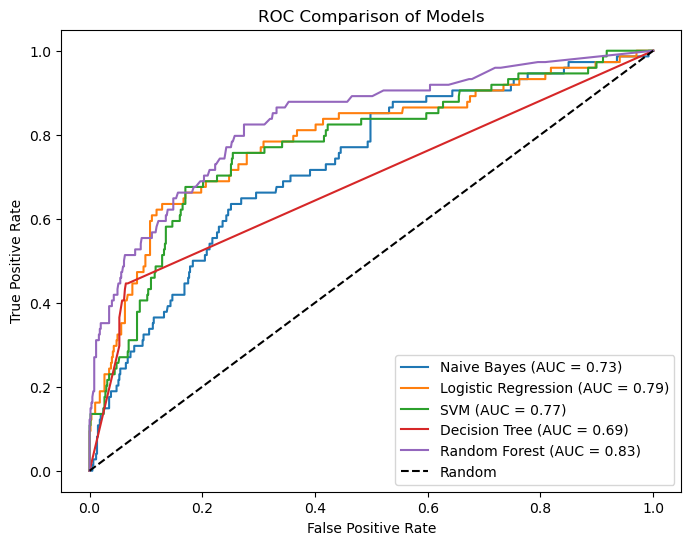

,Threshold Used,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUC
Random Forest,0.500,0.911765,0.647980,0.718750,0.310811,0.433962,0.832832
Logistic Regression,0.500,0.891176,0.583043,0.500000,0.189189,0.274510,0.788400
SVM (Youden J = 0.114),0.114,0.891176,0.500000,0.000000,0.000000,0.000000,0.774418
SVM (default 0.5),0.500,0.891176,0.500000,0.000000,0.000000,0.000000,0.774418
Naive Bayes,0.500,0.755882,0.661359,0.232558,0.540541,0.325203,0.728682
Decision Tree,0.500,0.883824,0.656030,0.457627,0.364865,0.406015,0.688041


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import pandas as pd
import matplotlib.pyplot as plt


# -------------------------------------------------
# User-defined threshold for SVM from earlier Youden's J analysis
# -------------------------------------------------

svm_youden_threshold = 0.114


# -------------------------------------------------
# Define model pipelines
# -------------------------------------------------

models = {
    "Naive Bayes": Pipeline([
        ("var", VarianceThreshold()),
        ("clf", BernoulliNB())
    ]),

    "Logistic Regression": Pipeline([
        ("var", VarianceThreshold()),
        ("clf", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "SVM (default 0.5)": Pipeline([
        ("var", VarianceThreshold()),
        ("clf", SVC(
            kernel="linear",
            probability=True,
            random_state=42
        ))
    ]),

    "SVM (Youden J = 0.114)": Pipeline([
        ("var", VarianceThreshold()),
        ("clf", SVC(
            kernel="linear",
            probability=True,
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("var", VarianceThreshold()),
        ("clf", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("var", VarianceThreshold()),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ])
}


# -------------------------------------------------
# Train models and collect metrics
# -------------------------------------------------

results = {}

plt.figure(figsize=(8, 6))

for name, model in models.items():

    model.fit(X_train, y_train)

    # Probability scores for ROC/AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # -------------------------------------------------
    # Apply model-specific prediction rule
    # -------------------------------------------------
    if name == "SVM (Youden J = 0.114)":
        y_pred = (y_prob >= svm_youden_threshold).astype(int)
        threshold_used = svm_youden_threshold
    else:
        y_pred = model.predict(X_test)
        threshold_used = 0.5

    # -------------------------------------------------
    # Metrics
    # -------------------------------------------------
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1_val = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Threshold Used": threshold_used,
        "Accuracy": acc,
        "Balanced Accuracy": bal_acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1_val,
        "AUC": auc
    }

    # -------------------------------------------------
    # ROC curve
    # Note: both SVM rows will generate the same ROC curve,
    # because ROC depends on y_prob, not the chosen threshold.
    # -------------------------------------------------
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    if name.startswith("SVM"):
        # Only plot one ROC curve for the two SVM variants
        if name == "SVM (default 0.5)":
            plt.plot(fpr, tpr, label=f"SVM (AUC = {auc:.2f})")
    else:
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")


# -------------------------------------------------
# Plot ROC comparison
# -------------------------------------------------

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison of Models")
plt.legend()
plt.show()


# -------------------------------------------------
# Display comparison table
# -------------------------------------------------

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[
    ["Threshold Used", "Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1", "AUC"]
]
comparison_df = comparison_df.sort_values(by="AUC", ascending=False)

comparison_df

In [ ]:
Copy the above code into this cell and alter so it also prints precision, recall and f1 score.

## Discussion

The table above compares the performance of multiple models trained on the same MACCS fingerprint representation. While overall accuracy is relatively high for most models, important differences emerge when considering recall, precision, and AUC.

Random Forest achieves the highest AUC (0.833) and overall accuracy, indicating strong ability to distinguish between active and inactive compounds. It also has the highest precision (0.719), suggesting that when it predicts a compound as active, it is often correct. However, its recall (0.311) remains moderate, indicating a conservative tendency that misses many actives.

Naive Bayes shows the highest recall (0.541) and balanced accuracy (0.661), meaning it identifies a larger fraction of active compounds. This comes at the cost of lower precision, reflecting a higher rate of false positives.

Logistic Regression provides a middle-ground performance, with moderate AUC (0.788) and relatively low recall (0.189), again indicating conservative predictions at the default threshold.

The SVM model presents an important contrast. At the default threshold of 0.5, it predicts no active compounds, resulting in zero recall and F1 score, despite having a reasonable AUC (0.774). This demonstrates that the model is capable of ranking compounds but fails to convert those rankings into useful classifications under the default decision rule.

When an optimized threshold is applied (Youden’s J = 0.114), the underlying SVM model remains unchanged, and the AUC is identical. However, the classification behavior changes because a different threshold is used to convert probabilities into class labels. This highlights that model evaluation depends not only on the algorithm, but also on the choice of decision threshold.

Overall, these results show that different models emphasize different aspects of performance, and that no single metric fully captures model behavior.

# 7 What Did These Models Learn from the Fingerprints?
All models in this comparison were trained on the same MACCS fingerprint representation, yet their performance differs significantly. This indicates that the choice of algorithm influences how the same structural information is interpreted.

Linear models such as Logistic Regression and SVM attempt to separate active and inactive compounds using a linear boundary in fingerprint space. The difficulty these models have in identifying actives suggests that the classes are not cleanly separable using simple linear relationships.

Naive Bayes treats each fingerprint bit as largely independent, allowing it to identify more actives but reducing precision. Tree-based models, particularly Random Forest, capture interactions between fingerprint features, leading to improved overall discrimination as reflected in higher AUC values.

The fact that no model achieves both high recall and high precision suggests that the MACCS fingerprints do not fully capture the structural patterns associated with activity in this dataset. Instead, activity appears to arise from more complex or subtle relationships that are only partially represented by these features.

This comparison highlights that model performance depends not only on the algorithm, but also on how well the chosen molecular representation encodes the underlying chemistry.